**Q2. UNSUPERVISED LEARNING**

Task 1 - Data Preperation

In [8]:
import pandas as pd
df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

**Note:**
*Why is Scaling essential?*

Scaling is important before applying K-Means because the algorithm uses distance based calculations.

Entries with larger values can dominate the distance metric, leading to incorrect grouping.

Standardising ensures all features/ entries contribute equally.

Task 2 - Choosing K-Elbow Method

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [11]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)

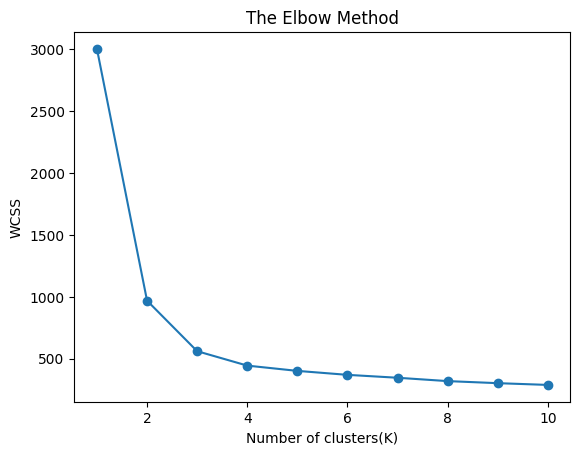

In [12]:
plt.plot(range(1,11),wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters(K)')
plt.ylabel('WCSS')
plt.show()

**Note:**

***Optimal K :***

From the plot, the optimal no. of clusters appears to be K = 3, where the decrease in WCSS starts slowing down significantly.

This point shows the balance between minimising within cluster variance and avoid excessive clustering.

Task 3 - K-Mean Clustering

In [13]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
clusters=kmeans.fit_predict(df_scaled)
df['cluster']=clusters
df.head()
centroids=pd.DataFrame(scaler.inverse_transform
 (kmeans.cluster_centers_),columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


**Note:**

***Cluster Interpretation***

Cluster 0: Represents customers with moderate spending & average visit frequency.

Cluster 1: Represents high value customers with high annual spend, frequent visits and larger basket sizes.

Cluster 2: Represents low value customers with lower spending, fewer visits and smaller baskets.

These can help businesses target different customer groups with personalised marketing strategies.

Task 4 - Dimensionality Reduction with PCA

In [14]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
result=pca.fit_transform(df_scaled)
df_pca=pd.DataFrame(result,columns=['PC1','PC2'])
df_pca['cluster']=clusters
df_pca.head()
print("Explained Variance Ratio: ",pca.explained_variance_ratio_)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)
loadings

Explained Variance Ratio:  [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


**Note:**

Interpretation of Principal Components

PC1 captures overall customer spending behavior, including features like annual spending & basket sizes.

PC2 captures customer activity patterns such visit frequency & when they last visited.

This helps simplify the dataset while retaining  meaningful patterns.

Task 5 - Cluster Visualisation

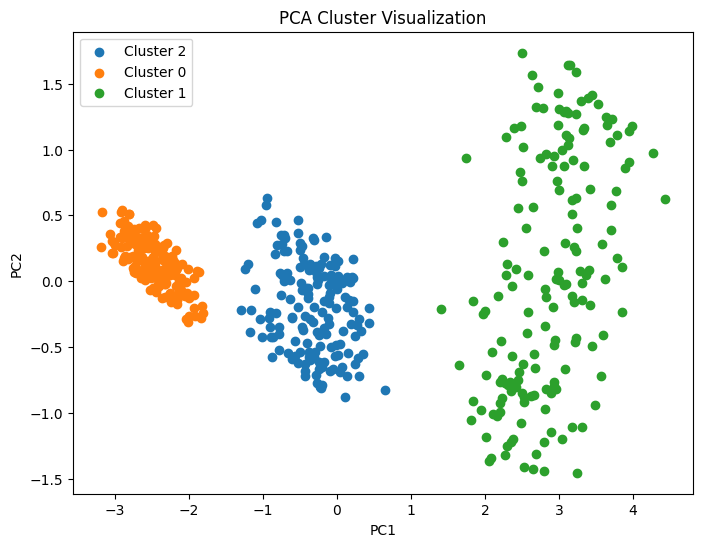

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
for cluster in df_pca['cluster'].unique():
  subset = df_pca[df_pca['cluster'] == cluster]
  plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')
plt.title('PCA Cluster Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

**Note:**

The plot shows us different customer groups.

The Clusters are seperated, which means the segmentation worked well.